In [8]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
import matplotlib.pyplot as plt
import numpy as np


In [9]:

# Load MNIST dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()


In [10]:

# Normalize images
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Generator
generator = Sequential([
    Dense(128, activation="relu", input_shape=(100,)),
    Dense(256, activation="relu"),
    Dense(28 * 28, activation="tanh"),
    Reshape((28, 28, 1))
])

# Discriminator
discriminator = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])


In [11]:

# Compile discriminator
discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Create GAN
discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


In [12]:

# Training parameters
epochs = 20
batch_size = 128

for epoch in range(epochs):

    # Select real images
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    # Generate fake images
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    # Train discriminator
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real_images.reshape(-1, 28, 28, 1),
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        fake_labels
    )


    # Train generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))

    g_loss = gan.train_on_batch(
        noise,
        real_labels
    )

    print(
        "Epoch:", epoch + 1,
        "D Loss:", (d_loss_real[0] + d_loss_fake[0]) / 2,
        "G Loss:", g_loss
    )

Epoch: 1 D Loss: 0.6963648200035095 G Loss: 0.7021867036819458
Epoch: 2 D Loss: 0.544658484053798 G Loss: 0.5243096351623535
Epoch: 3 D Loss: 0.6559909010356932 G Loss: 0.4596189260482788
Epoch: 4 D Loss: 0.7177079309722103 G Loss: 0.43738752603530884
Epoch: 5 D Loss: 0.6932001850336746 G Loss: 0.5226990580558777
Epoch: 6 D Loss: 0.5592917245739955 G Loss: 0.782781720161438
Epoch: 7 D Loss: 0.35773576271458296 G Loss: 1.3566612005233765
Epoch: 8 D Loss: 0.15750211104750633 G Loss: 2.3457279205322266
Epoch: 9 D Loss: 0.06798327155411243 G Loss: 3.3706371784210205
Epoch: 10 D Loss: 0.11115274578332901 G Loss: 3.6426868438720703
Epoch: 11 D Loss: 0.06490063108503819 G Loss: 3.1950912475585938
Epoch: 12 D Loss: 0.09165114560164511 G Loss: 2.8382649421691895
Epoch: 13 D Loss: 0.14592839463148266 G Loss: 2.7564263343811035
Epoch: 14 D Loss: 0.12562516902107745 G Loss: 3.1597604751586914
Epoch: 15 D Loss: 0.07859617657959461 G Loss: 3.750530242919922
Epoch: 16 D Loss: 0.12928441911935806 G Lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


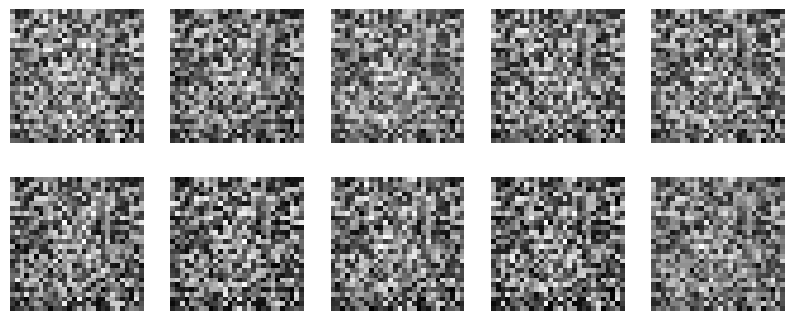

In [13]:
# Generate images
noise = np.random.normal(0, 1, (10, 100))
generated_images = generator.predict(noise)

# Display images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

c:\Users\ASUS\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 1 D Loss: 0.0983 G Loss: 5.2808
Epoch: 2 D Loss: 0.1165 G Loss: 7.5151
Epoch: 3 D Loss: 0.2745 G Loss: 4.2657
Epoch: 4 D Loss: 0.2649 G Loss: 2.1248
Epoch: 5 D Loss: 0.5015 G Loss: 1.395
Epoch: 6 D Loss: 0.7176 G Loss: 0.8952
Epoch: 7 D Loss: 0.5884 G Loss: 1.0971
Epoch: 8 D Loss: 0.507 G Loss: 1.1737
Epoch: 9 D Loss: 0.6253 G Loss: 0.9663
Epoch: 10 D Loss: 0.6272 G Loss: 0.9175
Epoch: 11 D Loss: 0.6863 G Loss: 0.8048
Epoch: 12 D Loss: 0.429 G Loss: 0.9638
Epoch: 13 D Loss: 0.653 G Loss: 0.896
Epoch: 14 D Loss: 0.4814 G Loss: 0.9397
Epoch: 15 D Loss: 0.8077 G Loss: 0.8863
Epoch: 16 D Loss: 0.4927 G Loss: 0.9461
Epoch: 17 D Loss: 0.4092 G Loss: 0.9253
Epoch: 18 D Loss: 0.7569 G Loss: 0.936
Epoch: 19 D Loss: 0.4581 G Loss: 1.0105
Epoch: 20 D Loss: 0.6236 G Loss: 1.0088
Epoch: 21 D Loss: 0.4158 G Loss: 0.9487
Epoch: 22 D Loss: 0.8081 G Loss: 0.8156
Epoch: 23 D Loss: 0.7595 G Loss: 1.257
Epoch: 24 D Loss: 0.4959 G Loss: 1.053
Epoch: 25 D Loss: 0.536 G Loss: 1.021
Epoch: 26 D Loss: 0

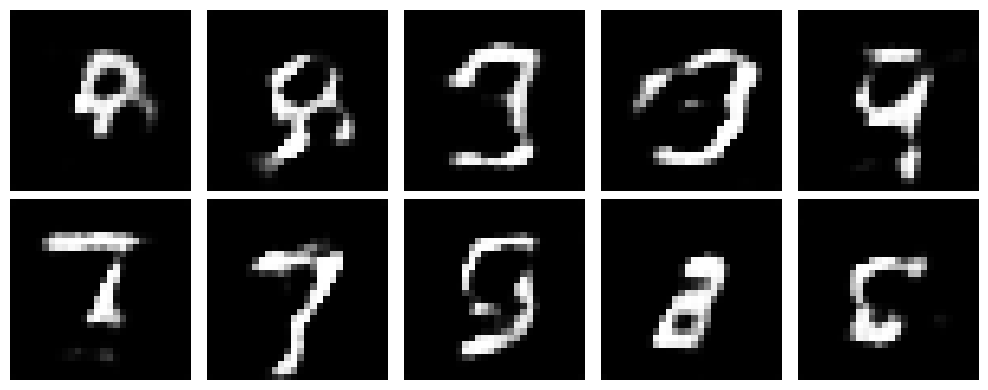

In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense, Reshape, Conv2D, Conv2DTranspose,
    LeakyReLU, BatchNormalization, Flatten
)
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Use a smaller dataset for faster training
X_train = X_train[:10000]

# Normalize images to -1 to 1
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

# -----------------------------
# Generator
# -----------------------------

generator = Sequential([
    Dense(7 * 7 * 128, input_shape=(100,)),
    BatchNormalization(),
    LeakyReLU(0.2),

    Reshape((7, 7, 128)),

    Conv2DTranspose(
        64, (4, 4),
        strides=(2, 2),
        padding="same"
    ),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2DTranspose(
        32, (4, 4),
        strides=(2, 2),
        padding="same"
    ),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2D(
        1, (3, 3),
        padding="same",
        activation="tanh"
    )
])

# -----------------------------
# Discriminator
# -----------------------------

discriminator = Sequential([
    Conv2D(
        64, (3, 3),
        strides=(2, 2),
        padding="same",
        input_shape=(28, 28, 1)
    ),
    LeakyReLU(0.2),

    Conv2D(
        128, (3, 3),
        strides=(2, 2),
        padding="same"
    ),
    LeakyReLU(0.2),

    Flatten(),

    Dense(1, activation="sigmoid")
])

# Compile discriminator
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Freeze discriminator while training generator
discriminator.trainable = False

# -----------------------------
# GAN
# -----------------------------

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy"
)

# -----------------------------
# Training
# -----------------------------

epochs = 30
batch_size = 64

for epoch in range(epochs):

    for step in range(len(X_train) // batch_size):

        # Real images
        idx = np.random.randint(
            0,
            X_train.shape[0],
            batch_size
        )

        real_images = X_train[idx]

        # Generate fake images
        noise = np.random.normal(
            0, 1,
            (batch_size, 100)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        # Labels
        real_labels = np.ones((batch_size, 1))
        fake_labels = np.zeros((batch_size, 1))

        # Train discriminator
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            real_images,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            fake_labels
        )

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(
            0, 1,
            (batch_size, 100)
        )

        g_loss = gan.train_on_batch(
            noise,
            real_labels
        )

    print(
        "Epoch:", epoch + 1,
        "D Loss:",
        round((d_loss_real[0] + d_loss_fake[0]) / 2, 4),
        "G Loss:",
        round(float(g_loss), 4)
    )

# -----------------------------
# Generate images
# -----------------------------

noise = np.random.normal(0, 1, (10, 100))

generated_images = generator.predict(
    noise,
    verbose=0
)

# Display images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()